In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
df = pd.read_csv(Path('/home/admin123/Documents/SAP/Div_academy/data/dirty_cafe_sales.csv'))
df.head()
df2 = df.copy()
df2.shape

(10000, 8)

In [3]:
df2.dropna(axis='rows')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9984,TXN_3142496,Smoothie,UNKNOWN,4.0,4.0,Cash,Takeaway,2023-07-27
9986,TXN_2858441,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3,4.0,12.0,Cash,Takeaway,2023-02-24
9992,TXN_2739140,Smoothie,4,4.0,16.0,UNKNOWN,In-store,2023-07-05


In [4]:
df2['Item'].value_counts()

Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
ERROR        292
Name: count, dtype: int64

In [5]:
df['Item']

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996         NaN
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: object

In [6]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()
output1 = ord_enc.fit_transform(df2[['Item']])
output1

array([[1.],
       [0.],
       [2.],
       ...,
       [1.],
       [2.],
       [6.]], shape=(10000, 1))

In [7]:
from sklearn.preprocessing import OneHotEncoder

ord_enc2 = OneHotEncoder(sparse_output=False)
output2 = ord_enc2.fit_transform(df2[['Item']])
output2

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 11))

In [8]:
ord_enc3 = OneHotEncoder(sparse_output=False)
output3 = ord_enc2.fit_transform(df2[['Payment Method']])
output3

array([[0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       ...,
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.]], shape=(10000, 6))

In [9]:
df2 = pd.read_csv(Path('/home/admin123/Documents/SAP/Div_academy/data/insurance.csv'))
df2




,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [10]:
df3 = pd.read_csv(Path('/home/admin123/Documents/SAP/Div_academy/Mall_Customers.csv'))
df3

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [11]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Income (k$)'}>,
        <Axes: title={'center': 'Spending Score (1-100)'}>]], dtype=object)

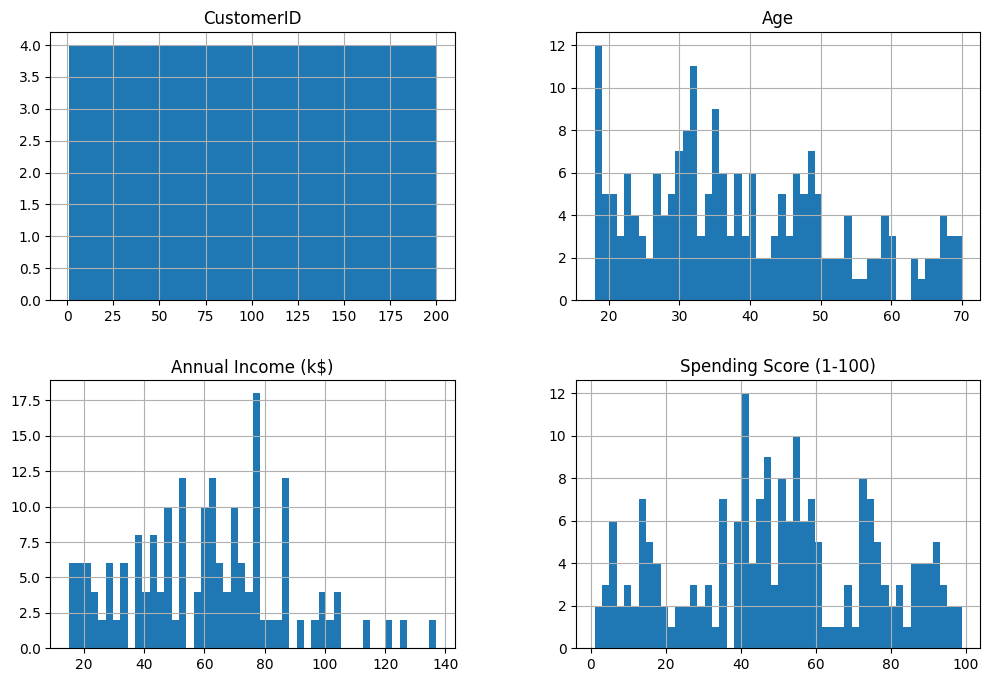

In [12]:
df3.hist(bins=50,figsize=(12,8))


In [14]:
df3.select_dtypes('number').columns

Index(['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

num_cols = ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
cat_cols = ['Gender']

num_pipline = Pipeline([
    ("scl",StandardScaler())
])
cat_pipline = Pipeline([
    ("enc",OrdinalEncoder())
])

preprocessing = ColumnTransformer([
    ("NUM", num_pipline, num_cols),
    ('CAT',cat_pipline,cat_cols)
])

df3_arr = preprocessing.fit_transform(df3)
df3_tr = pd.DataFrame(df3_arr, columns=preprocessing.get_feature_names_out())
df3_tr

,NUM__CustomerID,NUM__Age,NUM__Annual Income (k$),NUM__Spending Score (1-100),CAT__Gender
0,-1.723412,-1.424569,-1.738999,-0.434801,1.0
1,-1.706091,-1.281035,-1.738999,1.195704,1.0
2,-1.688771,-1.352802,-1.700830,-1.715913,0.0
3,-1.671450,-1.137502,-1.700830,1.040418,0.0
4,-1.654129,-0.563369,-1.662660,-0.395980,0.0
...,...,...,...,...,...
195,1.654129,-0.276302,2.268791,1.118061,0.0
196,1.671450,0.441365,2.497807,-0.861839,0.0
197,1.688771,-0.491602,2.497807,0.923953,1.0
198,1.706091,-0.491602,2.917671,-1.250054,1.0


array([[<Axes: title={'center': 'NUM__CustomerID'}>,
        <Axes: title={'center': 'NUM__Age'}>],
       [<Axes: title={'center': 'NUM__Annual Income (k$)'}>,
        <Axes: title={'center': 'NUM__Spending Score (1-100)'}>],
       [<Axes: title={'center': 'CAT__Gender'}>, <Axes: >]], dtype=object)

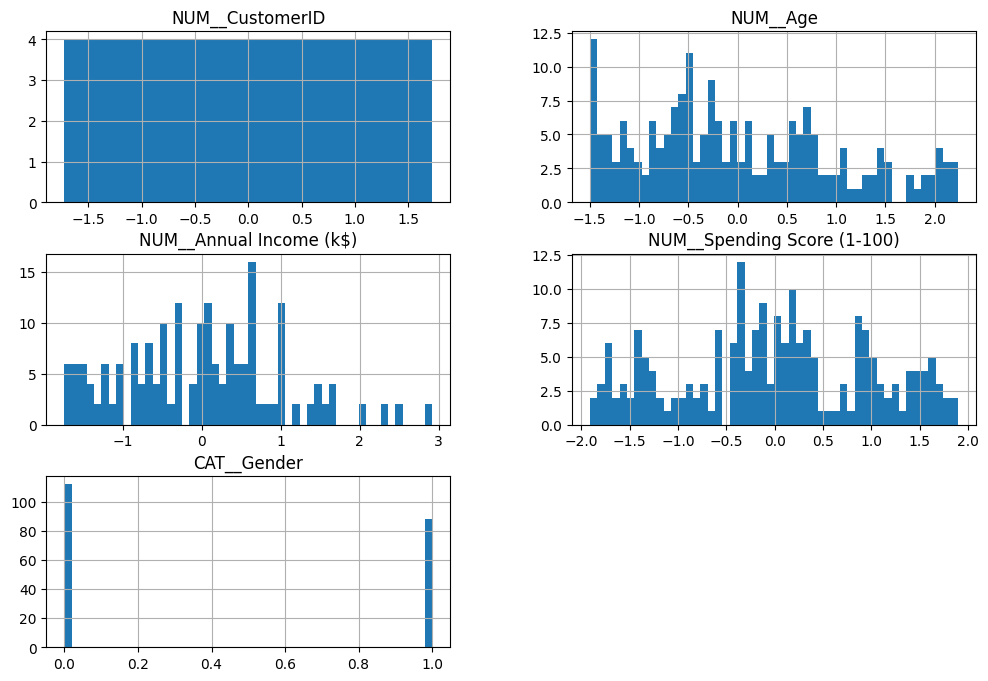

In [19]:
df3_tr.hist(bins=50,figsize=(12,8))

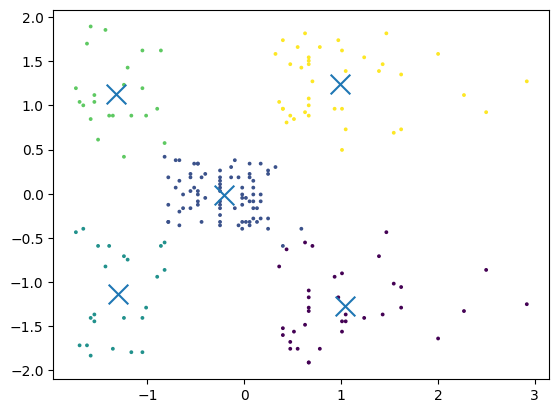

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
km = KMeans(n_clusters=5,random_state=10)
X = df3_tr[['NUM__Annual Income (k$)','NUM__Spending Score (1-100)']]
y_pred = km.fit_predict(X)
X = X.to_numpy()
plt.scatter(X[:,0],X[:,1],s=3,c=y_pred)
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1]
            ,marker='x',s=200)
plt.show()
